# Task 1: Data Preparation

In [13]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


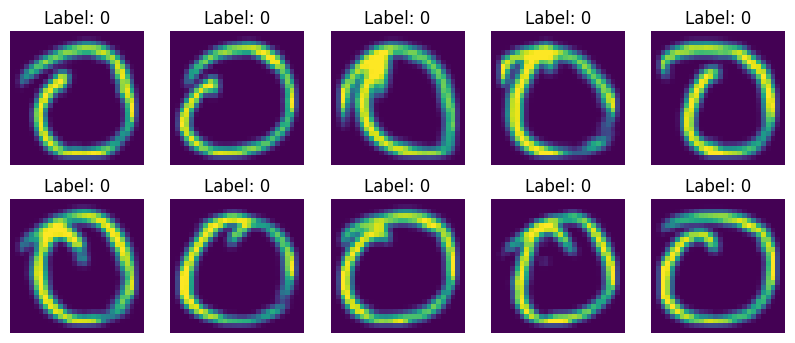

In [12]:

# Define dataset paths
train_dir = "/content/drive/MyDrive/KMS/aiml/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train/"
test_dir = "/content/drive/MyDrive/KMS/aiml/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test/"
# Define image size
img_height, img_width = 28, 28
# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
    class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            # Load image using PIL
            img = Image.open(img_path).convert("L") # Convert to grayscale
            img = img.resize((img_width, img_height)) # Resize to (28,28)
            img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
            images.append(img)
            labels.append(label)
    return np.array(images), np.array(labels)
# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)
# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)
# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")
# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28))
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.show()

# Task 2: Build the FCN Model

In [15]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

num_classes = 10
input_shape = (28, 28, 1)
model = tf.keras.Sequential(
[
tf.keras.layers.Input(shape=input_shape),
tf.keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
tf.keras.layers.Dense(64, activation="sigmoid"),
tf.keras.layers.Dense(128, activation="sigmoid"),
tf.keras.layers.Dense(256, activation="sigmoid"),
tf.keras.layers.Dense(num_classes, activation="softmax"),
]
)


# Task 3: Compile the Model

In [16]:

model.compile(
     optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Task 4: Train the Model

In [17]:
batch_size = 128
epochs = 20
# Callbacks
callbacks = [
tf.keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4 ),
]
# Train the model with callbacks and validation split
history = model.fit(
x_train,
y_train,
batch_size=batch_size,
epochs=epochs,
validation_split=0.15,
callbacks=callbacks,
)

Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4639 - loss: 1.7087 - val_accuracy: 0.1012 - val_loss: 4.9522
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8369 - loss: 0.5575 - val_accuracy: 0.2463 - val_loss: 5.4391
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9217 - loss: 0.2798 - val_accuracy: 0.2424 - val_loss: 5.9838
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9460 - loss: 0.1929 - val_accuracy: 0.2525 - val_loss: 6.1936
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9588 - loss: 0.1476 - val_accuracy: 0.2549 - val_loss: 6.3247


# Task 5: Evaluate the Model

In [20]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8493 - loss: 1.0773
Test Loss: 1.0773135423660278
Test Accuracy: 0.8493333458900452


In [21]:
model.save("devnagari_model.h5")

In [22]:
from tensorflow.keras.models import load_model

loaded_model = load_model("devnagari_model.h5")

loss, acc = loaded_model.evaluate(x_test, y_test)
print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8493 - loss: 1.0773
Loaded Model Accuracy: 0.8493333458900452


In [23]:
y_pred = model.predict(x_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [24]:
import numpy as np

y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

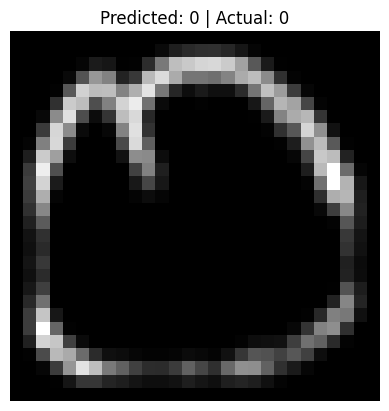

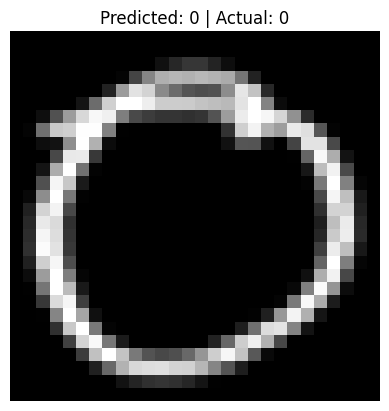

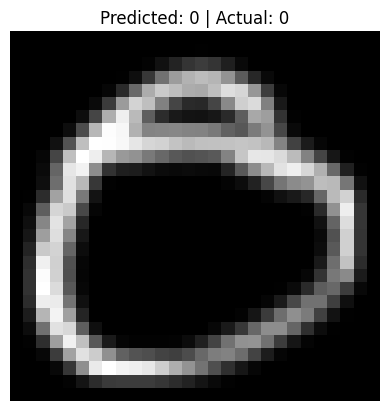

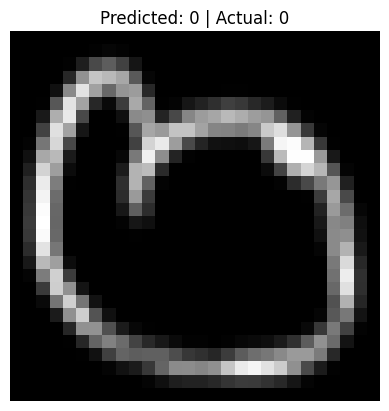

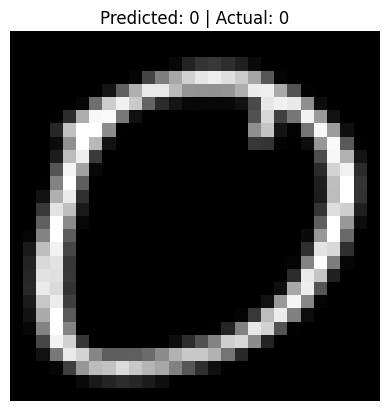

In [25]:
import matplotlib.pyplot as plt

for i in range(5):
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Predicted: {y_pred_labels[i]} | Actual: {y_true_labels[i]}")
    plt.axis('off')
    plt.show()

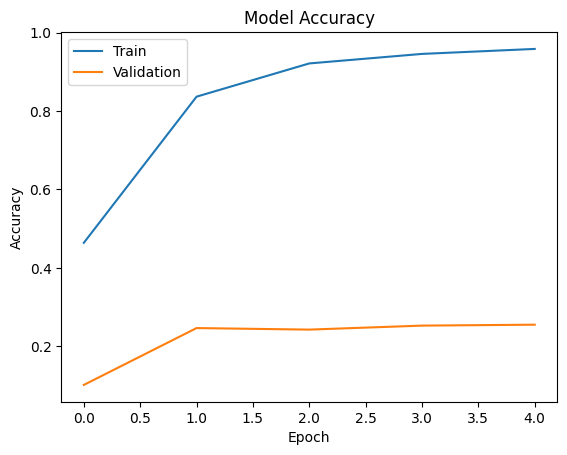

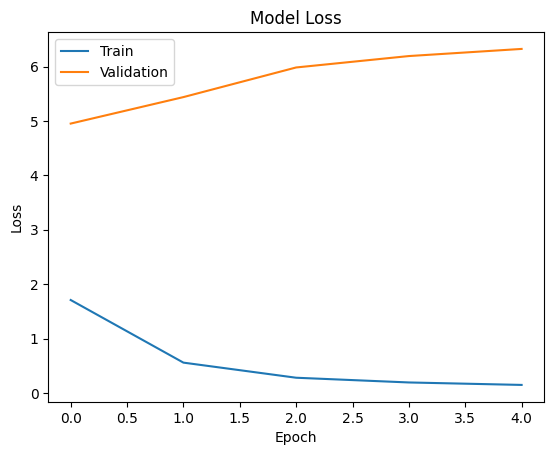

In [26]:
# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()